In [1]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
import warnings 
from sklearn.preprocessing import MinMaxScaler,StandardScaler
from sklearn.compose import ColumnTransformer
from imblearn.pipeline import Pipeline as ImbPipeline


warnings.filterwarnings('ignore')

In [2]:
df=pd.read_csv('CollegePlacement.csv')
df.head()

,College_ID,IQ,Prev_Sem_Result,CGPA,Academic_Performance,Internship_Experience,Extra_Curricular_Score,Communication_Skills,Projects_Completed,Placement
0,CLG0030,107,6.61,6.28,8,No,8,8,4,No
1,CLG0061,97,5.52,5.37,8,No,7,8,0,No
2,CLG0036,109,5.36,5.83,9,No,3,1,1,No
3,CLG0055,122,5.47,5.75,6,Yes,1,6,1,No
4,CLG0004,96,7.91,7.69,7,No,8,10,2,No


In [3]:
df.columns

Index(['College_ID', 'IQ', 'Prev_Sem_Result', 'CGPA', 'Academic_Performance',
       'Internship_Experience', 'Extra_Curricular_Score',
       'Communication_Skills', 'Projects_Completed', 'Placement'],
      dtype='object')

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   College_ID              10000 non-null  object 
 1   IQ                      10000 non-null  int64  
 2   Prev_Sem_Result         10000 non-null  float64
 3   CGPA                    10000 non-null  float64
 4   Academic_Performance    10000 non-null  int64  
 5   Internship_Experience   10000 non-null  object 
 6   Extra_Curricular_Score  10000 non-null  int64  
 7   Communication_Skills    10000 non-null  int64  
 8   Projects_Completed      10000 non-null  int64  
 9   Placement               10000 non-null  object 
dtypes: float64(2), int64(5), object(3)
memory usage: 781.4+ KB


In [5]:
df.describe()

,IQ,Prev_Sem_Result,CGPA,Academic_Performance,Extra_Curricular_Score,Communication_Skills,Projects_Completed
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,99.471800,7.535673,7.532379,5.546400,4.970900,5.561800,2.513400
std,15.053101,1.447519,1.470141,2.873477,3.160103,2.900866,1.715959
min,41.000000,5.000000,4.540000,1.000000,0.000000,1.000000,0.000000
25%,89.000000,6.290000,6.290000,3.000000,2.000000,3.000000,1.000000
50%,99.000000,7.560000,7.550000,6.000000,5.000000,6.000000,3.000000
75%,110.000000,8.790000,8.770000,8.000000,8.000000,8.000000,4.000000
max,158.000000,10.000000,10.460000,10.000000,10.000000,10.000000,5.000000


In [6]:
df.drop('College_ID',axis=1,inplace=True)

In [7]:
x=df.drop('Placement',axis=1)
y=df[['Placement']]
x.head()

,IQ,Prev_Sem_Result,CGPA,Academic_Performance,Internship_Experience,Extra_Curricular_Score,Communication_Skills,Projects_Completed
0,107,6.61,6.28,8,No,8,8,4
1,97,5.52,5.37,8,No,7,8,0
2,109,5.36,5.83,9,No,3,1,1
3,122,5.47,5.75,6,Yes,1,6,1
4,96,7.91,7.69,7,No,8,10,2


In [8]:
y.head()

,Placement
0,No
1,No
2,No
3,No
4,No


In [9]:
from collections import Counter

# Suppose your target column is y
class_counts = Counter(y['Placement'])

print(class_counts)


Counter({'No': 8341, 'Yes': 1659})


<Axes: >

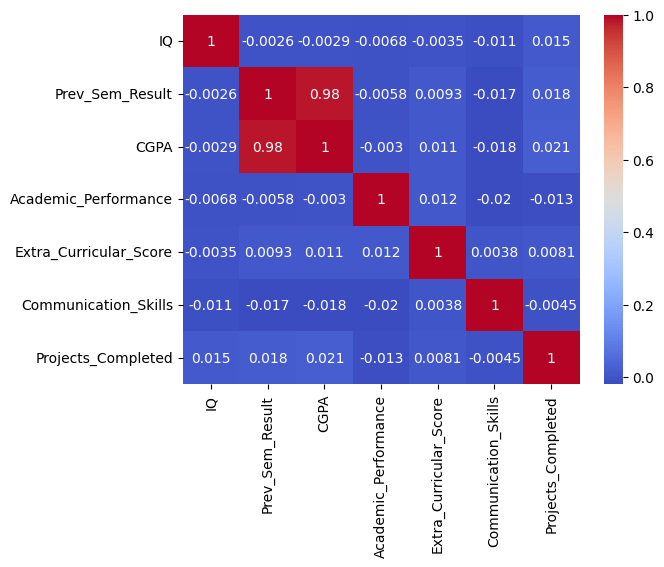

In [10]:
sns.heatmap(df.select_dtypes('number').corr(),cmap='coolwarm',annot=True)

In [11]:
x.drop('Prev_Sem_Result',axis=1,inplace=True)
x.columns

Index(['IQ', 'CGPA', 'Academic_Performance', 'Internship_Experience',
       'Extra_Curricular_Score', 'Communication_Skills', 'Projects_Completed'],
      dtype='object')

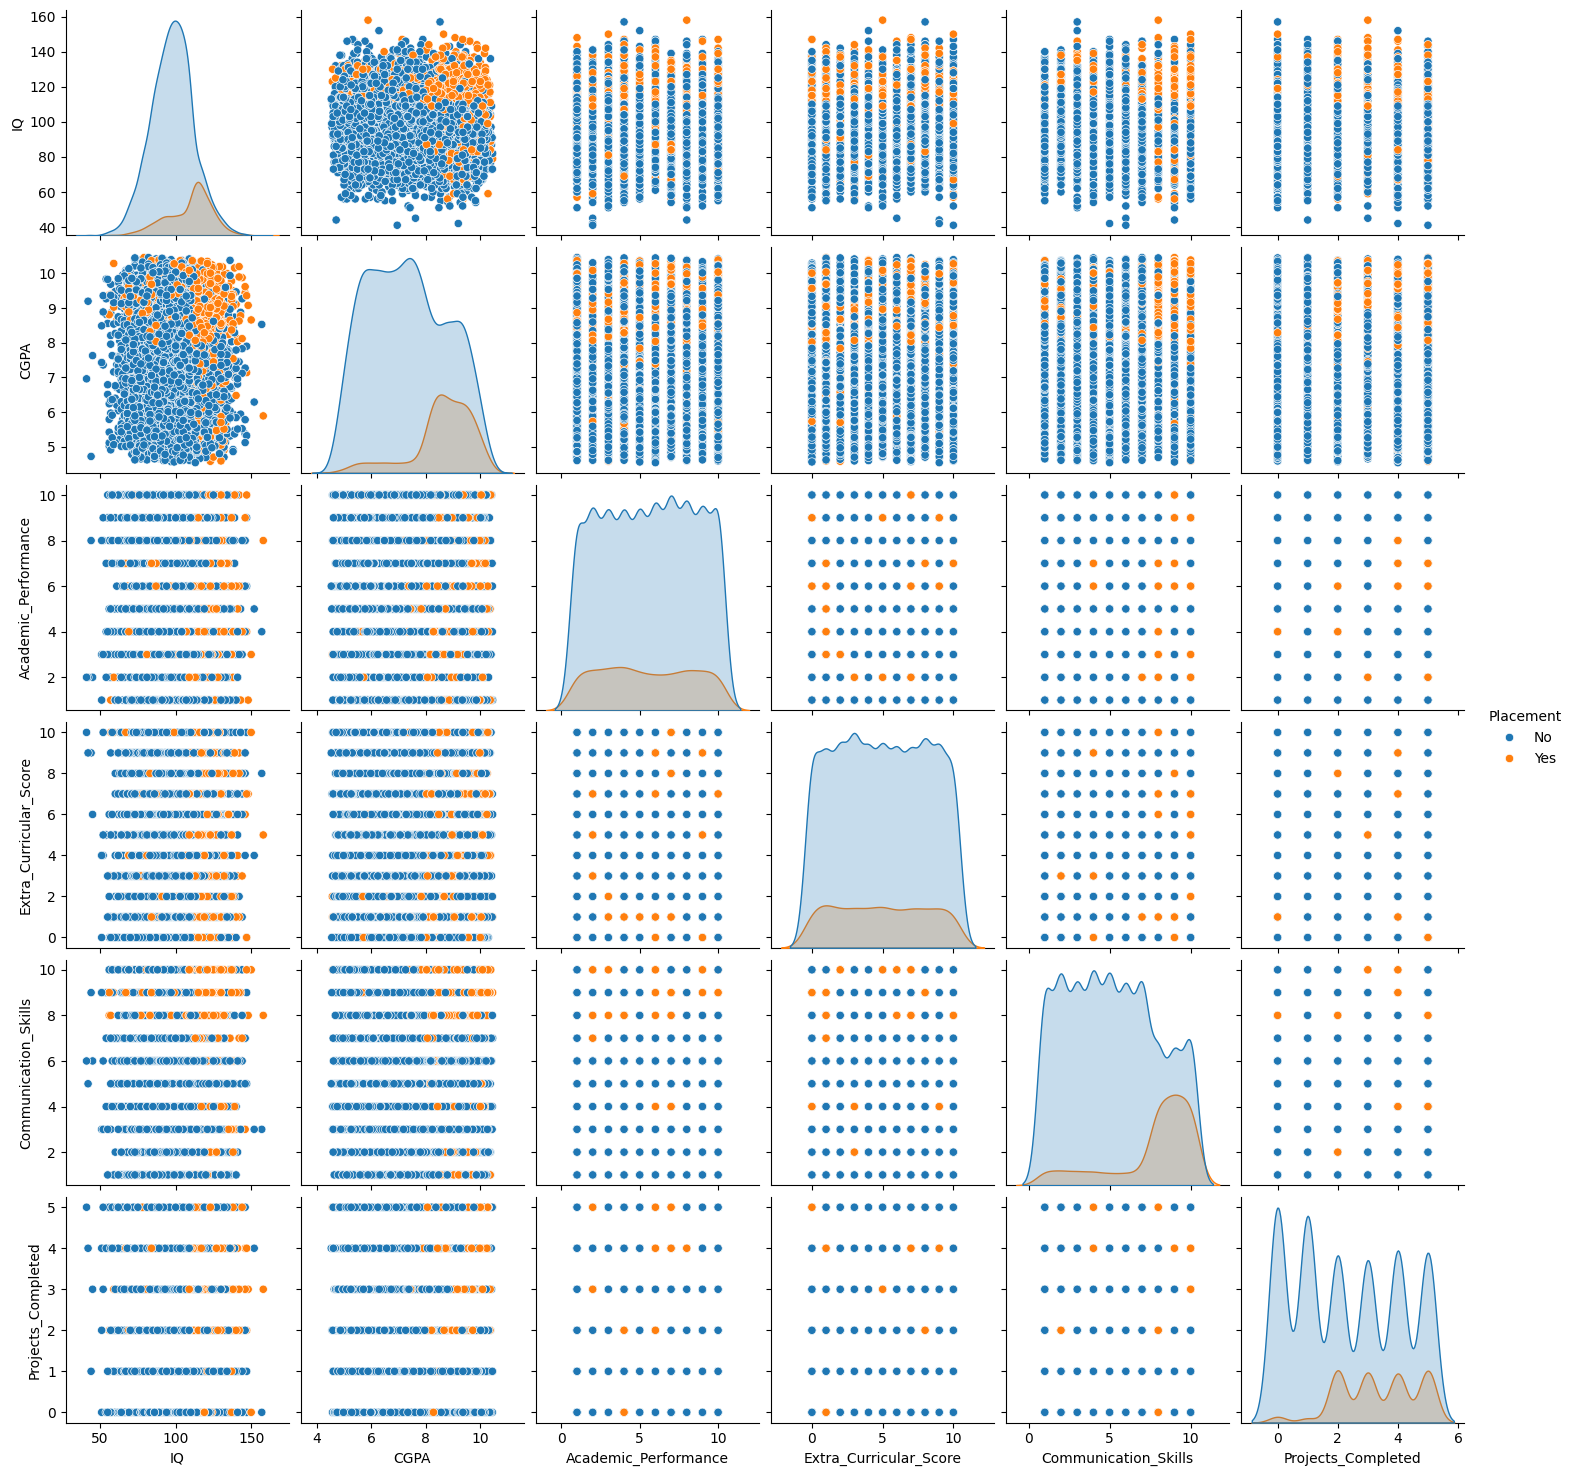

In [12]:
sns.pairplot(
    df,
    vars=['IQ', 'CGPA', 'Academic_Performance',
           'Extra_Curricular_Score',
          'Communication_Skills', 'Projects_Completed'],
    hue='Placement'
)


([0, 1, 2, 3, 4, 5],
 [Text(0, 0, 'IQ'),
  Text(1, 0, 'CGPA'),
  Text(2, 0, 'Academic_Performance'),
  Text(3, 0, 'Extra_Curricular_Score'),
  Text(4, 0, 'Communication_Skills'),
  Text(5, 0, 'Projects_Completed')])

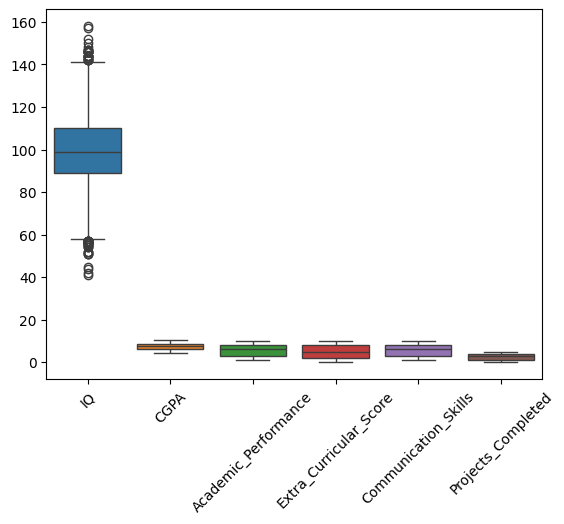

In [13]:
sns.boxplot(x[x.select_dtypes('number').columns])
plt.xticks(rotation=45)

In [14]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
x['Internship_Experience']=le.fit_transform(x['Internship_Experience'])
y['Placement']=le.fit_transform(y['Placement'])
x

,IQ,CGPA,Academic_Performance,Internship_Experience,Extra_Curricular_Score,Communication_Skills,Projects_Completed
0,107,6.28,8,0,8,8,4
1,97,5.37,8,0,7,8,0
2,109,5.83,9,0,3,1,1
3,122,5.75,6,1,1,6,1
4,96,7.69,7,0,8,10,2
...,...,...,...,...,...,...,...
9995,119,8.29,4,0,1,8,0
9996,70,9.34,7,0,0,7,2
9997,89,6.25,3,1,3,9,5
9998,107,8.92,3,0,7,5,1


In [15]:
y

,Placement
0,0
1,0
2,0
3,0
4,0
...,...
9995,1
9996,0
9997,0
9998,0


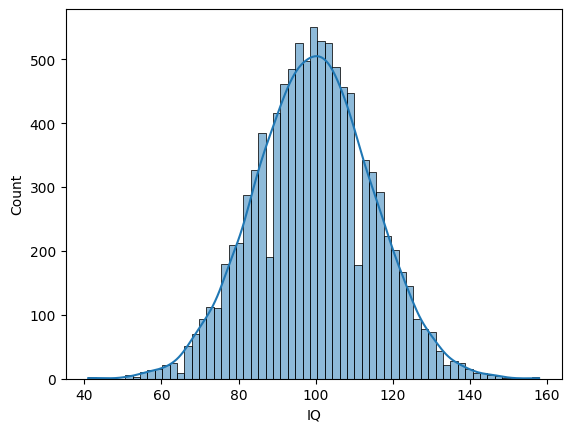

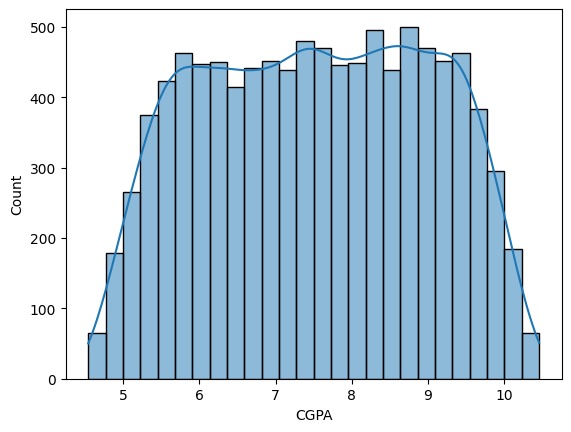

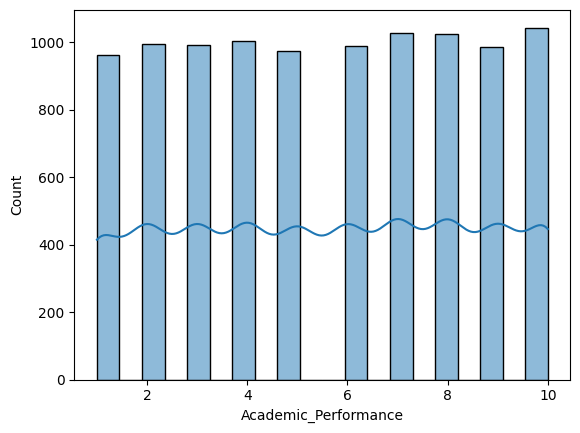

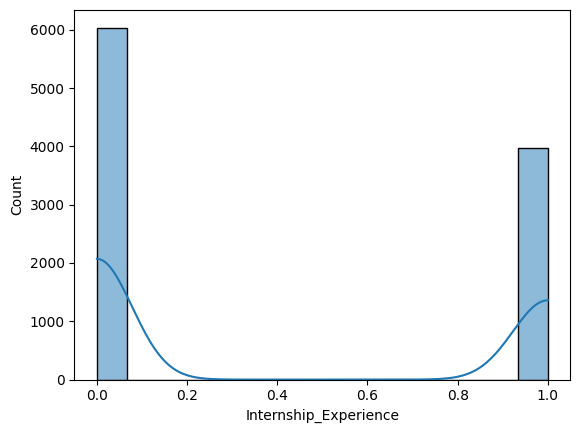

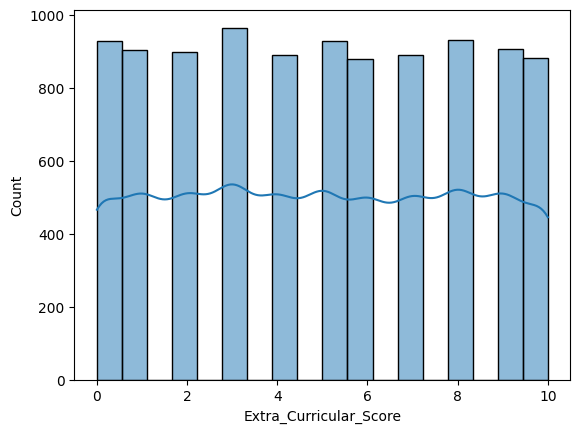

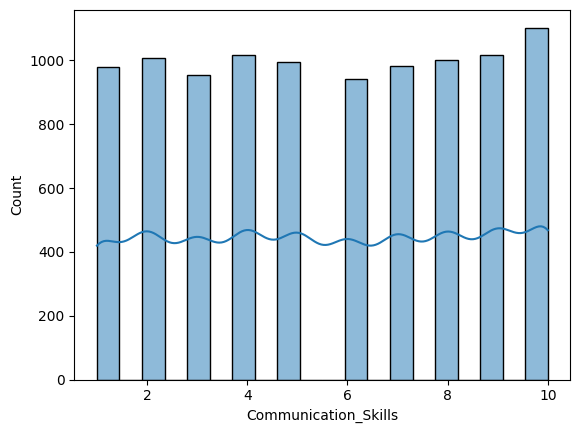

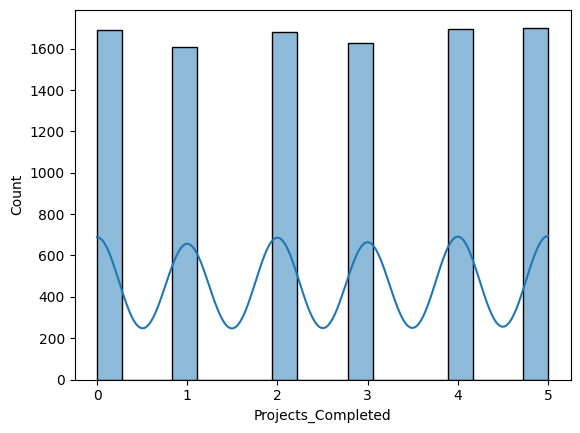

In [16]:
for i in x.columns:
    sns.histplot(x[i],kde=True)
    plt.show() 

In [17]:
x.columns

Index(['IQ', 'CGPA', 'Academic_Performance', 'Internship_Experience',
       'Extra_Curricular_Score', 'Communication_Skills', 'Projects_Completed'],
      dtype='object')

In [18]:
num_cols_mnmx=['IQ','CGPA']
num_cols_std=['Academic_Performance',
       'Internship_Experience', 'Extra_Curricular_Score',
       'Communication_Skills', 'Projects_Completed']

In [19]:
num_cols_mnmx

['IQ', 'CGPA']

In [20]:

preprocessor=ColumnTransformer(
    transformers=[
        ('minmax',MinMaxScaler(),num_cols_mnmx,),
        ('Standard',StandardScaler(),num_cols_std,),
    ],
    remainder='passthrough'        # keep other columns if any'
)

In [21]:
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier


Pipeline=ImbPipeline(
    steps=[
        ('preprocess',preprocessor),
        ('smote',SMOTE(random_state=42)),
        ('model',RandomForestClassifier(random_state=42))
    ]
)

In [22]:
from sklearn.model_selection import train_test_split,GridSearchCV
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.3,random_state=42)
x_train.head()

,IQ,CGPA,Academic_Performance,Internship_Experience,Extra_Curricular_Score,Communication_Skills,Projects_Completed
9069,110,8.25,3,0,2,2,4
2603,82,7.98,1,0,1,3,5
7738,103,9.30,2,1,5,6,3
1579,87,9.03,1,1,2,4,4
5058,97,5.61,8,1,5,6,3


In [23]:
y_train.head()

,Placement
9069,0
2603,0
7738,0
1579,0
5058,0


In [24]:
x_test.head()

,IQ,CGPA,Academic_Performance,Internship_Experience,Extra_Curricular_Score,Communication_Skills,Projects_Completed
6252,139,7.24,8,0,8,4,4
4684,84,8.49,8,1,3,3,5
1731,94,5.66,8,0,7,10,4
4742,100,6.29,6,1,8,6,3
4521,116,6.39,6,0,2,9,5


In [25]:
y_test.head()

,Placement
6252,0
4684,0
1731,0
4742,0
4521,1


In [26]:
df_corr=x.copy()
df_corr['Target']=y
df_corr.head()

,IQ,CGPA,Academic_Performance,Internship_Experience,Extra_Curricular_Score,Communication_Skills,Projects_Completed,Target
0,107,6.28,8,0,8,8,4,0
1,97,5.37,8,0,7,8,0,0
2,109,5.83,9,0,3,1,1,0
3,122,5.75,6,1,1,6,1,0
4,96,7.69,7,0,8,10,2,0


<Axes: >

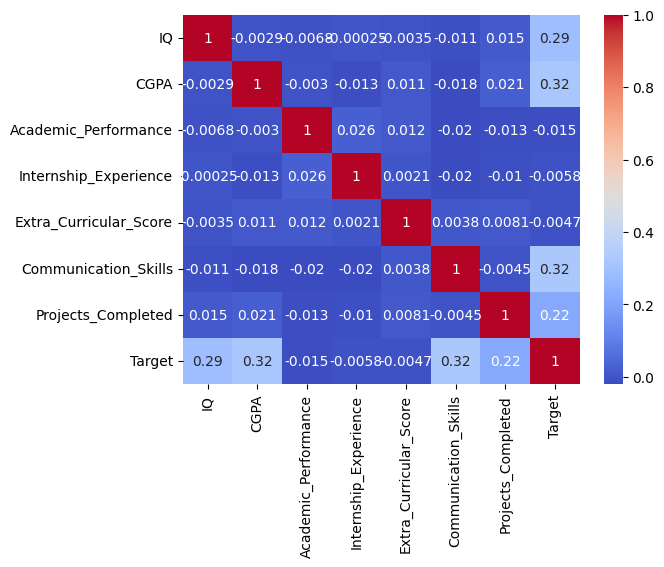

In [27]:
sns.heatmap(df_corr.corr(),cmap='coolwarm',annot=True)

<Axes: xlabel='Placement', ylabel='count'>

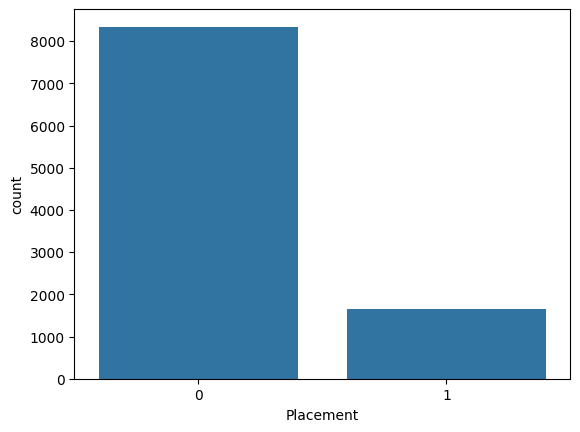

In [28]:
sns.countplot(x=y['Placement'])

In [29]:
param_grid = {
    'model__n_estimators': [50, 100, 200, 300, 500]
}

grid = GridSearchCV(
    estimator=Pipeline,
    param_grid=param_grid,
    scoring='accuracy',
    cv=5,
    n_jobs=-1,
    verbose=2
)

In [30]:
grid.fit(x_train,y_train)

Fitting 5 folds for each of 5 candidates, totalling 25 fits


,estimator,Pipeline(step...m_state=42))])
,param_grid,"{'model__n_estimators': [50, 100, ...]}"
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,5
,verbose,2
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('minmax', ...), ('Standard', ...)]"


In [31]:
ypred=grid.predict(x_test)
ypred

array([0, 0, 0, ..., 1, 0, 1], shape=(3000,))

In [32]:
res=pd.DataFrame(columns=['actual','predicted'])
res['actual']=y_test
res['predicted']=ypred
res.reset_index()
res.head()

,actual,predicted
6252,0,0
4684,0,0
1731,0,0
4742,0,0
4521,1,1


Accuracy: 0.999
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      2511
           1       1.00      1.00      1.00       489

    accuracy                           1.00      3000
   macro avg       1.00      1.00      1.00      3000
weighted avg       1.00      1.00      1.00      3000



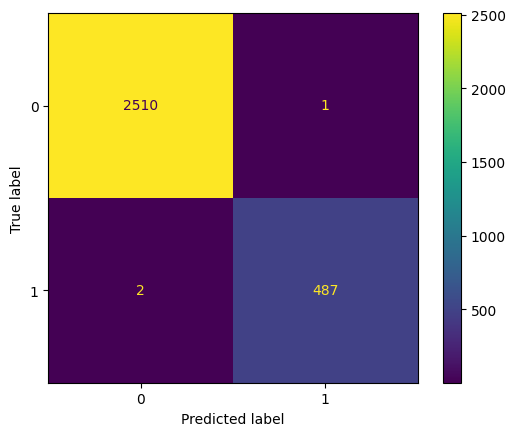

In [33]:
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_test, ypred))
print(classification_report(y_test, ypred))
ConfusionMatrixDisplay.from_estimator(grid, x_test, y_test)
plt.show()